<a href="https://colab.research.google.com/github/marcuslee6/Signal-and-Systems/blob/main/Discretization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

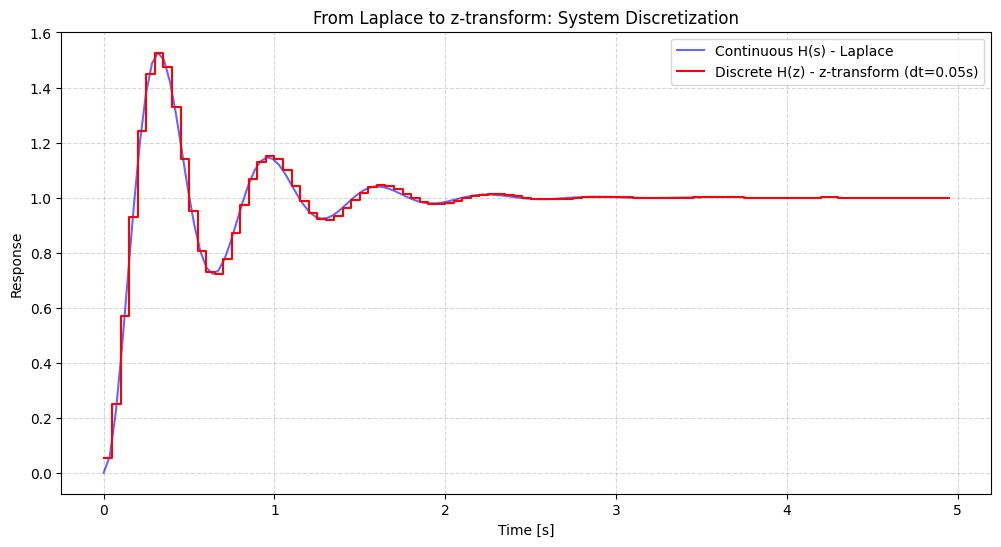

Discrete Transfer Function H(z) coefficients:
Numerator (b): [0.05376344 0.10752688 0.05376344]
Denominator (a): [ 1.         -1.61290323  0.82795699]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Define H(s) (Second-Order System)
wn = 10.0 # Natural Frequency
zeta = 0.2 # Damping Ratio
num = [wn**2]
den = [1, 2*zeta*wn, wn**2]
sys_continuous = signal.TransferFunction(num, den)

# 2. Discretization
# Set sampling time dt = 0.05 秒 (20Hz Sampling Frequency)
dt = 0.05
sys_discrete = sys_continuous.to_discrete(dt, method='bilinear')

# 3. Simulate Response
t_con, y_con = signal.step(sys_continuous)
t_dis, y_dis = signal.dstep(sys_discrete)

# 4. Graph Comparison
plt.figure(figsize=(12, 6))
plt.plot(t_con, y_con, label='Continuous H(s) - Laplace', color='blue', alpha=0.6)
plt.step(t_dis, np.squeeze(y_dis), label=f'Discrete H(z) - z-transform (dt={dt}s)', color='red', where='post')

plt.title("From Laplace to z-transform: System Discretization")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Output z-domain H(z) coefficients
print("Discrete Transfer Function H(z) coefficients:")
print(f"Numerator (b): {sys_discrete.num}")
print(f"Denominator (a): {sys_discrete.den}")
